# Grid World Visualization--Part I
Consider a grid world modeled using a 2D numpy array of dimension of $10\times 10$. There are 10 robots moving in the field. Write a function, named `display_grid` that takes the current locations of all robots as inputs, and displays the locations of all robots. Use appropriate plot to display the locations, and clearly label your plot. Read the documentation of `xlim` and `ylim`, and use them to make sure that the whole grid can be displayed in your plot.

An example of robot locations, i.e., input to the function, is given below:

```py
 location = np.array([[9 8],
                    [8 7],
                    [9 3],
                    [4 3],
                    [3 1],
                    [3 2],
                    [2 7],
                    [4 4],
                    [0 0],
                    [5 4]])
```
Each row of the input array corresponds to an agent. The first column represents the row indices of all agents, and the second column represents the column indices of all agents in the field. An exmaple output is given below:
![Example output](assets/robot_location.png)

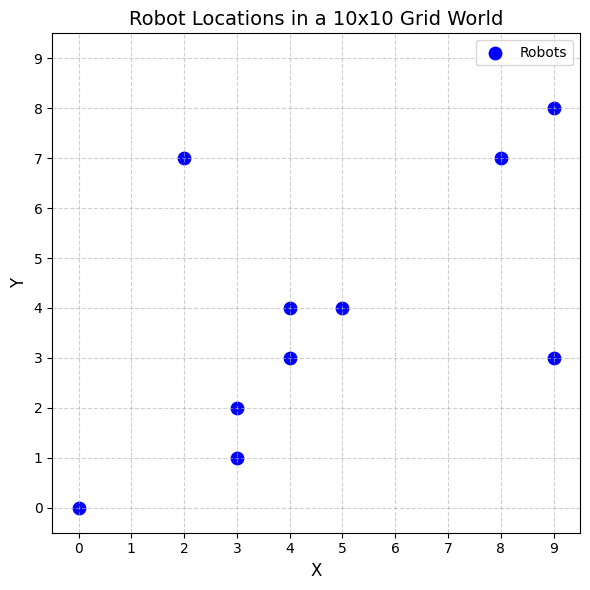

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def display_grid(locations):
    """
    Display robot locations in a 10x10 grid world.

    Parameters:

    locations : np.ndarray
        A (N, 2) array. Each row is [x, y],
        representing the position of one robot on the grid.
    """

    # Treat the first column as x-coordinates and the second as y-coordinates
    x = locations[:, 0]
    y = locations[:, 1]

    # Create the plot
    plt.figure(figsize=(6, 6))

    # Plot robots as blue dots
    plt.scatter(x, y, s=80, c="blue", label="Robots")

    # Add title and axis labels
    plt.title("Robot Locations in a 10x10 Grid World", fontsize=14)
    plt.xlabel("X", fontsize=12)
    plt.ylabel("Y", fontsize=12)

    # Set axis limits to show the entire 10x10 grid (0–9)
    plt.xlim(-0.5, 9.5)
    plt.ylim(-0.5, 9.5)

    # Add ticks and grid lines
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.grid(True, linestyle="--", alpha=0.6)

    # Add legend and adjust layout
    plt.legend()
    plt.tight_layout()

    # Display the plot
    plt.show()


# Example usage with coordinates treated as (x, y)
location = np.array([[9, 8],
                     [8, 7],
                     [9, 3],
                     [4, 3],
                     [3, 1],
                     [3, 2],
                     [2, 7],
                     [4, 4],
                     [0, 0],
                     [5, 4]])

display_grid(location)


# Grid World Visualization--Part II
Each robot can take one out of four actions: ["up", "down", "left", "right"], indicating the direction towards which the robot will move. If the moving direction will make the robot go outside the boundary of the grid world, then the robot will remain at its current location.

Write a function named `update_location` that takes the current location and action of a robot as inputs, and return its updated location. Feel free to verify your code by plotting the locations of robot before and after taking actions.

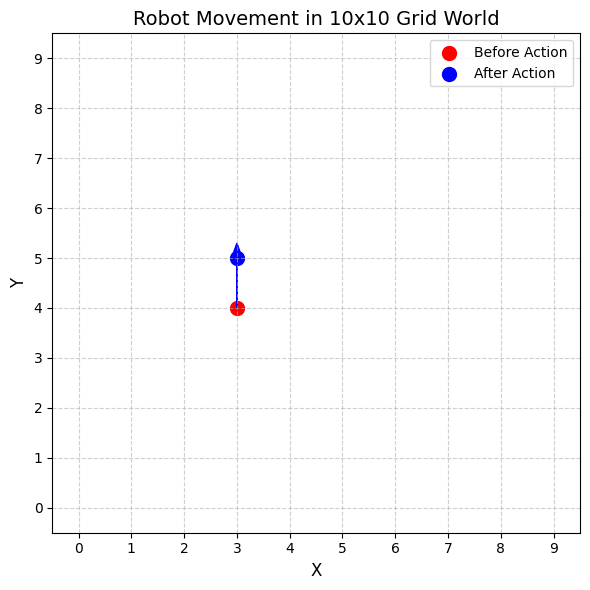

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def update_location(location, action):
    """
    Update the robot's location based on the given action.

    Parameters:

    location : array-like
        Current (x, y) position of the robot.
    action : str
        One of ["up", "down", "left", "right"].

    Returns:

    np.ndarray
        Updated (x, y) position. If movement goes out of bounds (0–9),
        the robot stays at the original position.
    """

    x, y = location  # unpack current position

    # Determine new coordinates based on the action
    if action == "up":
        new_x, new_y = x, y + 1
    elif action == "down":
        new_x, new_y = x, y - 1
    elif action == "left":
        new_x, new_y = x - 1, y
    elif action == "right":
        new_x, new_y = x + 1, y
    else:
        raise ValueError("Action must be one of: up, down, left, right.")

    # Check boundaries (0 to 9)
    if 0 <= new_x <= 9 and 0 <= new_y <= 9:
        return np.array([new_x, new_y])
    else:
        return np.array([x, y])  # remain at original location


def display_before_after(old_loc, new_loc):
    """
    Visualize the robot's position before and after taking an action.

    Parameters:

    old_loc : array-like
        Original (x, y) location.
    new_loc : array-like
        Updated (x, y) location after the action.
    """

    # Extract coordinates
    x_old, y_old = old_loc
    x_new, y_new = new_loc

    plt.figure(figsize=(6, 6))

    # Plot old location (red)
    plt.scatter(x_old, y_old, s=100, c="red", label="Before Action")

    # Plot new location (blue)
    plt.scatter(x_new, y_new, s=100, c="blue", label="After Action")

    # Draw arrow if the robot moved
    if not (x_old == x_new and y_old == y_new):
        plt.arrow(
            x_old, y_old,
            x_new - x_old, y_new - y_old,
            head_width=0.2, head_length=0.3, fc='blue', ec='blue'
        )

    # Title and labels
    plt.title("Robot Movement in 10x10 Grid World", fontsize=14)
    plt.xlabel("X", fontsize=12)
    plt.ylabel("Y", fontsize=12)

    # Grid and limits
    plt.xlim(-0.5, 9.5)
    plt.ylim(-0.5, 9.5)
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage

old_location = np.array([3, 4])
action = "up"

new_location = update_location(old_location, action)

display_before_after(old_location, new_location)


# Infectious Disease Visualization
Revise your function "simulate_disease" from previous assignment to achieve the following goals. The function should print out the statistic information of the infection probability at the end of prediction horizon, including minimum, maximum, average, and standard deviation.

The function should also plot how the infection probabilities of all individuals evolve over the prediction horizon. Pick appropriate visualization plot and clearly label your plot. You do not need to generate legends for the plot. 


Infection probability statistics at final time step:
  Minimum:            0.1925
  Maximum:            0.1925
  Mean (average):     0.1925
  Standard deviation: 0.0000


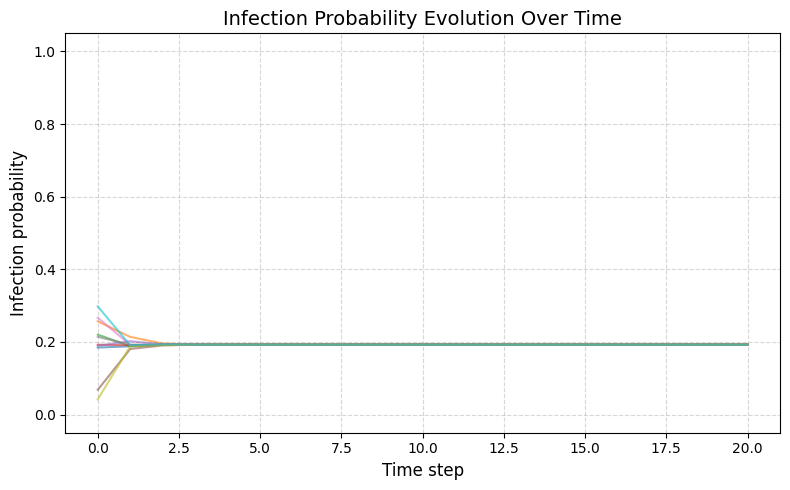


Shape of returned infection history: (21, 10)
First time step (t=0): [0.1845399  0.25669625 0.22031449 0.19228312 0.18941978 0.06817009
 0.2666515  0.21406537 0.04200418 0.29788495]
Final time step (t=steps): [0.19250816 0.19250816 0.19250816 0.19250816 0.19250816 0.19250816
 0.19250816 0.19250816 0.19250816 0.19250816]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_disease(p0: np.ndarray, connection_matrix: np.ndarray, steps: int) -> np.ndarray:
    """
    Simulate disease propagation over a network using p_{t+1} = W p_t,
    print statistics at the final time step, and plot the evolution
    of infection probabilities for all individuals.

    Parameters:

    p0 : np.ndarray
        Initial infection probabilities, shape (N,) or (N, 1).
    connection_matrix : np.ndarray
        Symmetric, row-stochastic (after normalization), non-negative
        matrix W of shape (N, N).
    steps : int
        Number of update steps (prediction horizon), must be >= 0.

    Returns:

    np.ndarray
        Infection probabilities over time as a 2-D array of shape
        (steps + 1, N). Each row corresponds to one time step, where
        row 0 is the initial infection vector p0.
    """
    # Convert inputs to proper numeric arrays
    p = np.asarray(p0, dtype=float).reshape(-1)      # flatten to shape (N,)
    W = np.asarray(connection_matrix, dtype=float)   # ensure float array

    # Validate dimensions
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError("connection_matrix must be square (N, N).")
    if W.shape[0] != p.shape[0]:
        raise ValueError("len(p0) must equal W.shape[0].")
    if np.any(W < 0):
        raise ValueError("connection_matrix must be non-negative.")
    if steps < 0:
        raise ValueError("steps must be a non-negative integer.")

    # Normalize rows to make matrix row-stochastic (row sums = 1)
    row_sums = W.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0):
        raise ValueError("Each row must have a positive sum.")
    W = W / row_sums

    N = p.shape[0]

    # Allocate an array to store infection probabilities over time
    # Shape: (steps + 1, N), where row 0 is the initial state
    infection_history = np.zeros((steps + 1, N), dtype=float)
    infection_history[0] = p

    # Iterative propagation: p_{t+1} = W p_t
    for t in range(1, steps + 1):
        p = W @ p
        p = np.clip(p, 0.0, 1.0)  # ensure probabilities stay within [0, 1]
        infection_history[t] = p

    # Statistics at the end of the prediction horizon
    final_probs = infection_history[-1]  # shape: (N,)

    min_prob = np.min(final_probs)
    max_prob = np.max(final_probs)
    mean_prob = np.mean(final_probs)
    std_prob = np.std(final_probs)

    print("Infection probability statistics at final time step:")
    print(f"  Minimum:            {min_prob:.4f}")
    print(f"  Maximum:            {max_prob:.4f}")
    print(f"  Mean (average):     {mean_prob:.4f}")
    print(f"  Standard deviation: {std_prob:.4f}")

    # Plot the evolution of infection probabilities
    time_steps = np.arange(steps + 1)  # 0, 1, ..., steps

    plt.figure(figsize=(8, 5))

    # Plot one line per individual
    # infection_history has shape (steps + 1, N)
    for i in range(N):
        plt.plot(time_steps, infection_history[:, i], alpha=0.6)

    plt.title("Infection Probability Evolution Over Time", fontsize=14)
    plt.xlabel("Time step", fontsize=12)
    plt.ylabel("Infection probability", fontsize=12)

    # Infection probabilities are in [0, 1], so we fix the y-axis range
    plt.ylim(-0.05, 1.05)

    # Add a light grid; legend is not required by the assignment
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return infection_history


# Example Usage

if __name__ == "__main__":
    # Number of individuals (nodes)
    N = 10

    # Initial infection probabilities (random example)
    # You can manually specify this array as well.
    p0 = np.random.uniform(0.0, 0.3, size=N)

    # Example connection matrix W (random symmetric non-negative matrix)
    # Then normalized inside the function.
    rng = np.random.default_rng(seed=0)
    A = rng.uniform(0.0, 1.0, size=(N, N))
    A = (A + A.T) / 2  # make symmetric
    np.fill_diagonal(A, 1.0)  # self-connections (optional)
    
    # Prediction horizon (number of update steps)
    steps = 20

    # Run the simulation
    infection_history = simulate_disease(p0, A, steps)

    # infection_history has shape (steps+1, N)
    print("\nShape of returned infection history:", infection_history.shape)
    print("First time step (t=0):", infection_history[0])
    print("Final time step (t=steps):", infection_history[-1])


# Image Downsampling
Write a function named `downsample_image`. The function takes a grayscale image and an integer downsampling rate as input and outputs a filtered version of the image. The input image is represented by a 2D numpy array. You can assume the image is of a square shape, and the image size is larger than downsampling rate. To downsample the image, we follow the steps below:
- Partition the image into a collection of smaller blocks. Each block is of dimension $k\times k$, where $k$ is the downsampling rate. If the original image is of dimension $N\times N$, then the rows and columns are partitions into $\frac{N}{k}$ segments, respectively. The output image should then be of dimension $\frac{N}{k}\times \frac{N}{k}$.
- For each block associated with $i$-th row segment, and $j$-th column segment, calculate the average of all pixels within the block, and the average is $(i,j)$-th pixel in output image is assigned as the average. 


Your function should display the downsampled image. An example of the downsampling process is given below:
![downsample process](assets/filter.gif)

The red block in this example is sometimes referred to as a kernel. The kernel in this example is known as a moving average filter. 

Please use this image to test your function. Although this is a colorful image, you can convert it to grayscale using the code below and then pass it to the function:

```py
from PIL import Image
img = Image.open('sample_image_2.jpg').convert('L') # load image in gray scale
img_array = np.array(img) # 8-bit code grayscale
```
See an example of downsampled image with downsampling rate=5:

![downsampled image](assets/dsimg.png)


Revise your function to downsample a colorful image. Note that a colorful image can be represented as a 3D numpy array, where the 3rd dimension represents the RGB channels.

**Extra challenge** (this challenge is not graded): This challenge will test your code efficiency. You need to improve your code to achieve runtime . Please use the following code to test your efficiency:


In [ ]:
timeit -n 1 -r 7 img_ds2 = downsample_image(image=img_array, downsampling_rate=5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def downsample_image(image: np.ndarray, downsampling_rate: int) -> np.ndarray:
    """
    Downsample a grayscale or RGB image using block-wise averaging.

    The image is partitioned into non-overlapping k x k blocks, where k is the
    downsampling_rate. Each block is replaced by the average of its pixels,
    resulting in a smaller image of size (N/k, N/k) for grayscale or
    (N/k, N/k, 3) for RGB images.

    Parameters:

    image : np.ndarray
        Input image as a NumPy array. For grayscale images, the shape should be
        (N, N). For color images (RGB), the shape should be (N, N, 3).
    downsampling_rate : int
        The size of the block (k). Must be a positive integer that divides N.

    Returns:

    np.ndarray
        The downsampled image as a NumPy array. The data type is preserved
        (e.g., uint8 for typical images).

    Notes:

    The function also displays the downsampled image using matplotlib.
    For grayscale images, a gray colormap is used. For RGB images, the
    image is shown directly.
    """

    if downsampling_rate <= 0:
        raise ValueError("downsampling_rate must be a positive integer.")

    # Ensure image is a NumPy array
    img = np.asarray(image)
    original_dtype = img.dtype

    # Handle grayscale (2D) and color (3D) images separately
    if img.ndim == 2:
        # Grayscale image: shape (N, N)
        N, M = img.shape
        if N != M:
            raise ValueError("Grayscale image must be square (N x N).")
        if N % downsampling_rate != 0:
            raise ValueError("Image size N must be divisible by downsampling_rate.")

        k = downsampling_rate
        new_size = N // k

        # Convert to float for averaging
        img_float = img.astype(float)

        # Reshape into blocks: (new_size, k, new_size, k)
        blocks = img_float.reshape(new_size, k, new_size, k)

        # Average over the block dimensions (k, k)
        downsampled = blocks.mean(axis=(1, 3))

    elif img.ndim == 3:
        # Color image (RGB): shape (N, N, C), typically C == 3
        N, M, C = img.shape
        if N != M:
            raise ValueError("Color image must be square (N x N).")
        if N % downsampling_rate != 0:
            raise ValueError("Image size N must be divisible by downsampling_rate.")

        k = downsampling_rate
        new_size = N // k

        # Convert to float for averaging
        img_float = img.astype(float)

        # Reshape into blocks: (new_size, k, new_size, k, C)
        blocks = img_float.reshape(new_size, k, new_size, k, C)

        # Average over the block dimensions (k, k), keep channel dimension
        downsampled = blocks.mean(axis=(1, 3))

    else:
        raise ValueError("Image must be either 2D (grayscale) or 3D (RGB).")

    # Convert back to original dtype if it is an integer type (e.g., uint8)
    if np.issubdtype(original_dtype, np.integer):
        downsampled = np.clip(downsampled, 0, 255).astype(original_dtype)

    # Display the downsampled image
    plt.figure(figsize=(5, 5))
    if downsampled.ndim == 2:
        # Grayscale visualization
        plt.imshow(downsampled, cmap="gray")
    else:
        # Color visualization
        plt.imshow(downsampled)
    plt.title(f"Downsampled Image (k={downsampling_rate})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return downsampled


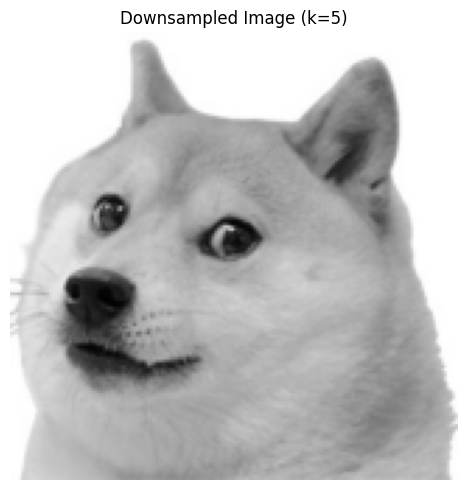

In [13]:
from PIL import Image
import numpy as np

# Load image in grayscale
img = Image.open(r"C:\Users\HP\Desktop\509_demo\assignment-6-visualization-Sienna-Zhang\assets\sample_image_2.jpg").convert("L")
img_array = np.array(img)  # 2D array, dtype uint8

# Downsample with k = 5
img_ds_gray = downsample_image(image=img_array, downsampling_rate=5)


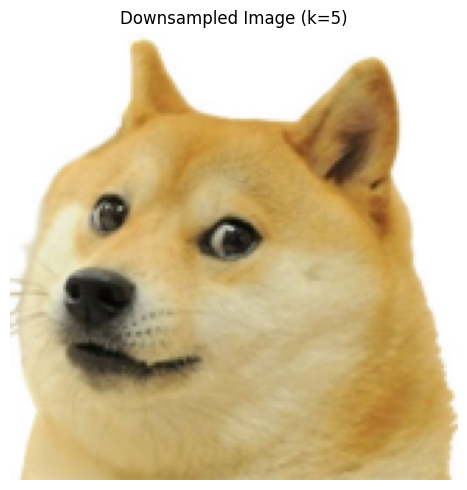

In [14]:
from PIL import Image
import numpy as np

# Load image in RGB (color)
img_color = Image.open(r"C:\Users\HP\Desktop\509_demo\assignment-6-visualization-Sienna-Zhang\assets\sample_image_2.jpg").convert("RGB")
img_color_array = np.array(img_color)  # 3D array (N, N, 3)

# Downsample with k = 5
img_ds_color = downsample_image(image=img_color_array, downsampling_rate=5)


# Word Embedding
LLMs represent words as high dimensional vectors (also known as embeddings). You’ll explore how simple embeddings can capture semantic meanings. Example embeddings of a limited vocabulary are provided below.
- Can you propose a metric to measure the similarity between a pair of words? **Hint**: You have seen a measure in previous assignments.
- Choose an appropriate visualization to show which words are most similar to each other.
- What word do you obtain for `king – man + woman` using vector arithmetic? Does this result make sense to you? Why or why not.

In [ ]:
embeddings = {
  "king": [
    1.0, 1.0, 1.0, 0.0, 0.8, 0.9, 0.0, 0.0, 0.0, 0.0
  ] + [0.0]*40,
  "queen": [
    1.0, -1.0, 1.0, 0.0, 0.8, 0.9, 0.0, 0.0, 0.0, 0.0
  ] + [0.0]*40,
  "man": [
    0.0, 1.0, 1.0, 0.0, 0.0, 0.9, 0.0, 0.0, 0.0, 0.0
  ] + [0.0]*40,
  "woman": [
    0.0, -1.0, 1.0, 0.0, 0.0, 0.9, 0.0, 0.0, 0.0, 0.0
  ] + [0.0]*40,
  "apple": [
    0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.7, 0.2, 0.6, 0.2
  ] + [0.0]*40,
  "banana": [
    0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.6, 0.8, 0.6, 0.7
  ] + [0.0]*40
}


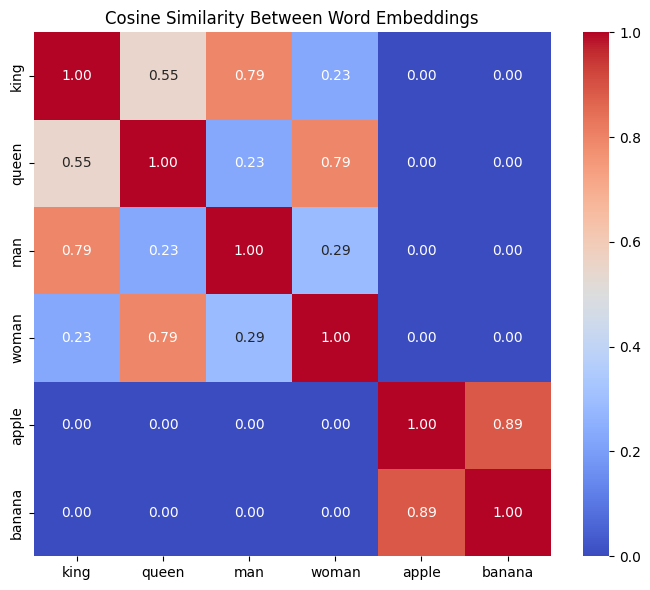

Result of king - man + woman: queen
Similarity: 1.0000000000000002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Provided word embeddings
embeddings = {
    "king":   [1.0, 1.0, 1.0, 0.0, 0.8, 0.9, 0.0, 0.0, 0.0, 0.0] + [0.0]*40,
    "queen":  [1.0,-1.0, 1.0, 0.0, 0.8, 0.9, 0.0, 0.0, 0.0, 0.0] + [0.0]*40,
    "man":    [0.0, 1.0, 1.0, 0.0, 0.0, 0.9, 0.0, 0.0, 0.0, 0.0] + [0.0]*40,
    "woman":  [0.0,-1.0, 1.0, 0.0, 0.0, 0.9, 0.0, 0.0, 0.0, 0.0] + [0.0]*40,
    "apple":  [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.7, 0.2, 0.6, 0.2] + [0.0]*40,
    "banana": [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.6, 0.8, 0.6, 0.7] + [0.0]*40,
}

# Convert to numpy arrays
for w in embeddings:
    embeddings[w] = np.array(embeddings[w], dtype=float)


# Cosine similarity function

def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


# Compute similarity matrix

words = list(embeddings.keys())
num_words = len(words)

sim_matrix = np.zeros((num_words, num_words))

for i in range(num_words):
    for j in range(num_words):
        sim_matrix[i, j] = cosine_similarity(embeddings[words[i]], embeddings[words[j]])


# Visualize similarity heatmap

plt.figure(figsize=(7, 6))
sns.heatmap(sim_matrix, annot=True, xticklabels=words, yticklabels=words,
            cmap="coolwarm", fmt=".2f")
plt.title("Cosine Similarity Between Word Embeddings")
plt.tight_layout()
plt.show()


# Word analogy: king - man + woman

analogy_vec = embeddings["king"] - embeddings["man"] + embeddings["woman"]

# Find the most similar word
best_word = None
best_sim = -999

for w in words:
    sim = cosine_similarity(analogy_vec, embeddings[w])
    if sim > best_sim:
        best_sim = sim
        best_word = w

print("Result of king - man + woman:", best_word)
print("Similarity:", best_sim)
